In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
main_df=pd.read_csv("../data/uae_ecom_fraud_100k.csv")

df = main_df.copy()

In [14]:
# Dropping columns with no predictive value identified during EDA
df.drop(columns=['transaction_id', 'currency', 'data_source', 'fraud_flag_velocity'], inplace=True)

---
## 16. Feature Engineering
### 16.1 Ratio Features
Ratio features help capture the relationship between two numerical variables — they often reveal patterns that individual features cannot.

In [15]:
# amount per avg item price — captures basket value relative to item cost
df['amount_per_item_price'] = df['amount_aed'] / df['avg_item_price']

# amount relative to card age — high spend on a new card is suspicious
df['amount_per_card_age'] = df['amount_aed'] / (df['card_age_days'] + 1)

### 16.2 Interaction Features
Interaction features combine two variables to capture combined risk signals that neither feature reveals alone.

In [16]:
# high ip risk score combined with high transaction amount increases fraud probability
df['amount_x_risk'] = df['amount_aed'] * df['ip_risk_score']

# fresh account making a high value purchase — strong fraud signal per dataset description
df['fresh_high_value'] = ((df['user_account_age_days'] < 14) & (df['amount_aed'] > 1000)).astype(int)

### 16.3 Behavioral Features
Behavioral features capture user activity patterns — unusual transaction frequency or spending habits can indicate fraudulent behavior.

In [17]:
# ratio of transactions in last hour vs last 24h — sudden spike indicates velocity attack
df['velocity_ratio'] = df['transactions_last_1h'] / (df['transactions_last_24h'] + 1)

# user-level aggregations — captures spending behavior per user
user_stats = df.groupby('user_id')['amount_aed'].agg(
    user_mean_amount='mean',
    user_std_amount='std',
    user_max_amount='max',
    user_txn_count='count'
).reset_index()

df = df.merge(user_stats, on='user_id', how='left')

# users with single transaction have no std — replacing NaN with 0
df['user_std_amount'] = df['user_std_amount'].fillna(0)

### 16.4 Time Features
Time-based features capture temporal patterns in fraud behavior — fraudsters often operate at specific times or days.


In [18]:
df['timestamp_utc'] = pd.to_datetime(df['timestamp_utc'])

# extract day of week and weekend flag from timestamp
df['day_of_week'] = df['timestamp_utc'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

df['hour_bin'] = pd.cut(
    df['local_hour'],
    bins=[0, 6, 12, 18, 24],
    labels=['night', 'morning', 'afternoon', 'evening'],
    right=False
)

### 16.5 Risk Aggregation
Combining multiple weak fraud signals into a single score — transactions with multiple risk flags are significantly more likely to be fraudulent, as confirmed in EDA.


In [19]:
# sum of all fraud flags — higher score indicates higher combined risk
flag_cols = [
    'fraud_flag_ip',
    'fraud_flag_mismatch',
    'fraud_flag_new_account',
    'fraud_flag_prev_cb',
    'fraud_flag_odd_hour'
]

df['combined_risk_score'] = df[flag_cols].sum(axis=1)

### 16.6 Email Features
Disposable email domains are a strong fraud signal — EDA showed ~20-23% fraud rate for temporary providers vs ~7-8% for legitimate ones.

In [20]:
# binary flag for disposable/temporary email domains — strong fraud signal identified in EDA
disposable_domains = ['tempmail', '10minutemail', 'disposable', 'mailinator', 'guerrillamail']
df['is_disposable_email'] = df['email_domain'].str.contains(
    '|'.join(disposable_domains), case=False, na=False
).astype(int)

df.drop(columns=['email_domain'], inplace=True)

---
## 17. Data Leakage Check
Fraud flags were engineered directly from the fraud label — if included in the model, they may cause data leakage. We analyze their correlation with is_fraud to decide whether to keep or drop them.


In [21]:
# checking which fraud flags exist in the dataset
flag_cols = [
    'fraud_flag_ip',
    'fraud_flag_mismatch',
    'fraud_flag_new_account',
    'fraud_flag_prev_cb',
    'fraud_flag_odd_hour'
]

# fraud rate with flags included
print("Fraud rate with flags:", df['is_fraud'].mean())

# correlation of flags with is_fraud
df[flag_cols + ['is_fraud']].corr()['is_fraud'].sort_values(ascending=False)

Fraud rate with flags: 0.08211


is_fraud                  1.000000
fraud_flag_prev_cb        0.121494
fraud_flag_new_account    0.076544
fraud_flag_ip             0.054778
fraud_flag_odd_hour       0.030257
fraud_flag_mismatch       0.019160
Name: is_fraud, dtype: float64

- All flag correlations with is_fraud are weak (max 0.12) — no direct leakage risk
- Flags can be computed in real-time in production (IP risk, odd hour, mismatch)
- Decision: keep all fraud flags — removing them would also weaken combined_risk_score

---
## 18. Encoding Strategy
Machine learning models require numerical inputs — categorical features must be encoded before modeling.
### 18.1 Categorical Encoding

In [22]:
# label encoding for binary/ordinal categoricals
from sklearn.preprocessing import LabelEncoder

binary_cols = ['device_type', 'browser', 'payment_method', 'merchant_category', 
               'shipping_city', 'billing_city', 'bin_country', 'hour_bin']

for col in binary_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

### 18.2 High Cardinality

In [23]:
# dropping ip_address as it has too many unique values for encoding — predictive info already captured via ip_risk_score
df.drop(columns=['ip_address'], inplace=True)

---
## 19. Feature Selection
### 19.1 Correlation with Target
Identifying features most correlated with is_fraud to understand which are strongest predictors.

In [24]:
# correlation of all numerical features with is_fraud
corr_with_fraud = df.select_dtypes(include=['int64', 'float64']).corr()['is_fraud'].sort_values(ascending=False)
print(corr_with_fraud)

is_fraud                  1.000000
fraud_flag_prev_cb        0.121494
user_prev_chargebacks     0.119735
combined_risk_score       0.116971
ip_risk_score             0.116704
user_is_high_risk         0.114228
is_disposable_email       0.085227
fraud_flag_new_account    0.076544
fraud_flag_ip             0.054778
amount_x_risk             0.043205
bin_country               0.032986
fraud_flag_odd_hour       0.030257
odd_hour                  0.030257
amount_aed                0.026427
hour_bin                  0.024500
avg_item_price            0.022684
fraud_flag_mismatch       0.019160
user_std_amount           0.016986
user_max_amount           0.016932
user_mean_amount          0.016769
fresh_high_value          0.015194
amount_per_card_age       0.012196
card_age_days             0.006842
amount_per_item_price     0.006403
items_count               0.006402
billing_city              0.002375
shipping_city             0.002276
user_txn_count            0.000486
card_present        

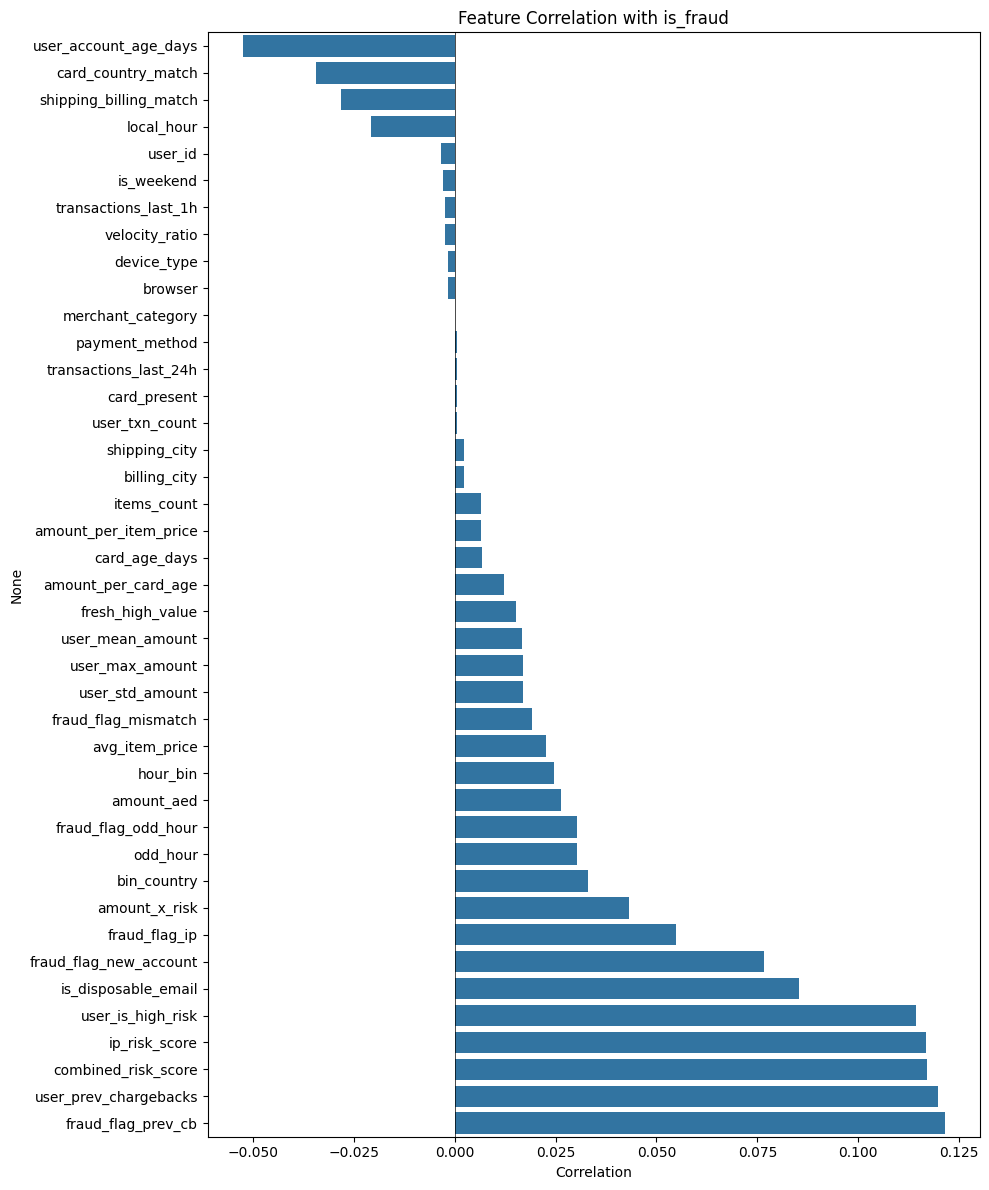

In [25]:
# visualizing feature correlations with is_fraud to identify strongest predictors
corr_with_fraud = df.select_dtypes(include=['int64', 'float64']).corr()['is_fraud'].drop('is_fraud').sort_values()

plt.figure(figsize=(10, 12))
sns.barplot(x=corr_with_fraud.values, y=corr_with_fraud.index)
plt.title('Feature Correlation with is_fraud')
plt.xlabel('Correlation')
plt.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

### 19.2 Drop Useless Features
Dropping features with near-zero correlation to is_fraud and redundant features to reduce noise and improve model performance.

In [26]:
# dropping weak, redundant and identifier columns based on correlation analysis
cols_to_drop = [
    'user_id',
    'timestamp_utc',
    'local_hour',
    'card_present',
    'transactions_last_24h',
    'transactions_last_1h',
    'payment_method',
    'merchant_category',
    'browser',
    'device_type',
    'velocity_ratio',
    'is_weekend',
    'user_txn_count',
    'billing_city',
    'shipping_city',
    'fraud_flag_odd_hour',  # same as odd_hour
]

df.drop(columns=cols_to_drop, inplace=True)

print("Remaining columns:", df.shape[1])
print(df.columns.tolist())

Remaining columns: 28
['amount_aed', 'items_count', 'avg_item_price', 'shipping_billing_match', 'ip_risk_score', 'bin_country', 'card_age_days', 'card_country_match', 'user_prev_chargebacks', 'user_is_high_risk', 'user_account_age_days', 'odd_hour', 'is_fraud', 'fraud_flag_ip', 'fraud_flag_mismatch', 'fraud_flag_new_account', 'fraud_flag_prev_cb', 'amount_per_item_price', 'amount_per_card_age', 'amount_x_risk', 'fresh_high_value', 'user_mean_amount', 'user_std_amount', 'user_max_amount', 'day_of_week', 'hour_bin', 'combined_risk_score', 'is_disposable_email']


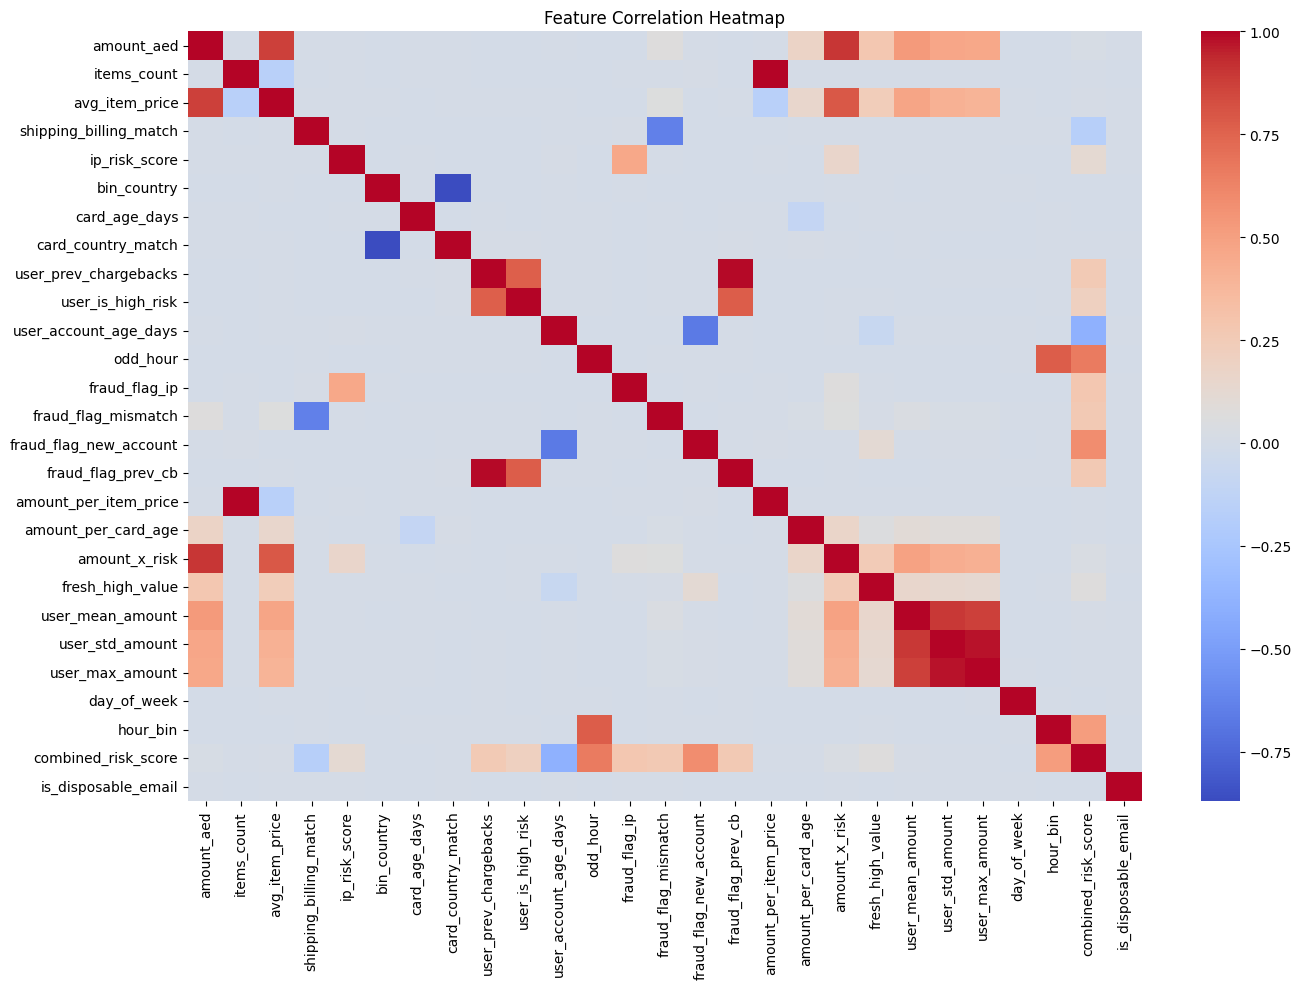

In [27]:
# checking multicollinearity between highly correlated features
high_corr = df.drop(columns=['is_fraud']).corr()

plt.figure(figsize=(14, 10))
sns.heatmap(high_corr, cmap='coolwarm', annot=False)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

In [28]:
# dropping multicollinear features
cols_to_drop = [
    'user_prev_chargebacks',  # captured by fraud_flag_prev_cb and user_is_high_risk
    'user_std_amount',        # highly correlated with user_mean_amount
    'user_max_amount',        # highly correlated with user_mean_amount
]

df.drop(columns=cols_to_drop, inplace=True)
print("Remaining columns:", df.shape[1])

Remaining columns: 25


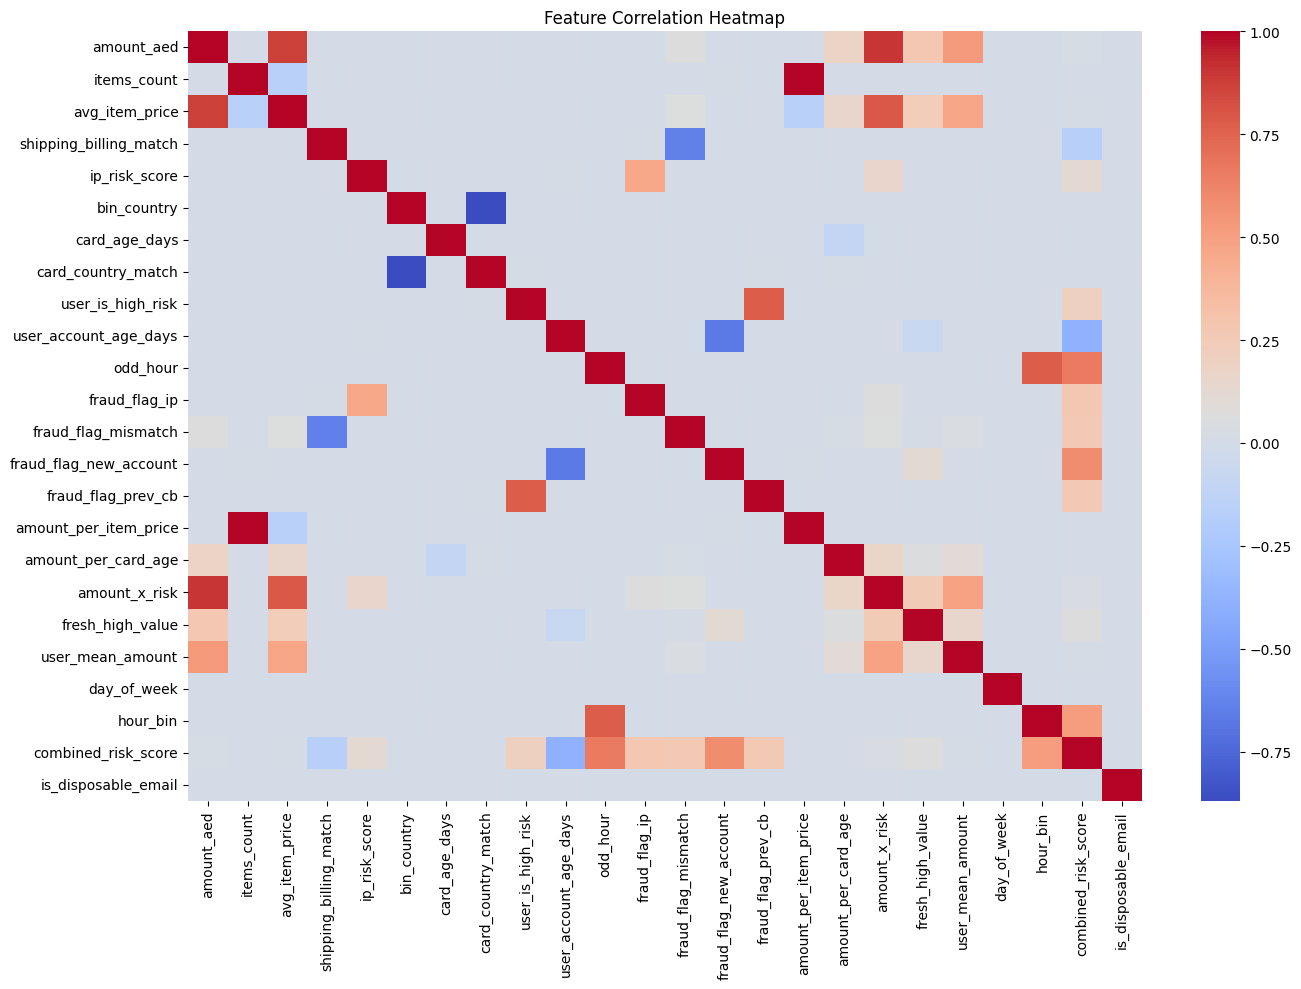

In [29]:
# checking multicollinearity between highly correlated features
high_corr = df.drop(columns=['is_fraud']).corr()

plt.figure(figsize=(14, 10))
sns.heatmap(high_corr, cmap='coolwarm', annot=False)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()